# German Automotive Stock Analysis and Price Prediction using LSTM

## Exploratory Data Analysis, Technical Indicators and Deep Learning

# Introduction

Financial time series forecasting is one of the most challenging problems in machine learning due to market volatility and nonlinear price movements.

This project investigates whether Long Short-Term Memory (LSTM) neural networks can predict future stock price movements of major German automotive manufacturers.

Companies analyzed:

- BMW
- Mercedes-Benz
- Volkswagen

The notebook combines Exploratory Data Analysis (EDA), Technical Analysis indicators (MACD and RSI), Feature Engineering and Deep Learning.

## Business Objective

The objective of this project is to investigate whether historical stock prices together with technical indicators can be used to predict future stock returns.

The study focuses on three major German automotive companies and evaluates their historical performance before training an LSTM neural network on BMW stock data.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Date & Time
import datetime as dt
from datetime import datetime

# Machine Learning
from sklearn.preprocessing import StandardScaler

# Deep Learning
import tensorflow as tf

# Financial Data
import yfinance as yf
from pandas_datareader import data as pdr
from pandas_datareader.data import DataReader

# Plot Settings
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")
%matplotlib inline

# Download Historical Stock Data

In [3]:
# German automotive companies
stock_symbols = ["VOW3.DE", "MBG.DE", "BMW.DE"]
company_names = ["Volkswagen", "Mercedes-Benz", "BMW"]

# Time period
start_date = dt.datetime(2019, 1, 1)
end_date = dt.datetime(2025, 12, 31)

# Download data
company_data = []

for ticker, company in zip(stock_symbols, company_names):

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        multi_level_index=False
    )

    data["Company"] = company

    company_data.append(data)

# Merge into one dataframe
stocks_df = pd.concat(company_data)

stocks_df.head()

,Close,High,Low,Open,Volume,Company
Date,,,,,,
2019-01-02,76.742249,78.195317,75.829860,78.195317,1116700,Volkswagen
2019-01-03,75.897453,76.956281,75.514478,76.032626,968713,Volkswagen
2019-01-04,79.118980,79.118980,76.505711,76.618351,1177680,Volkswagen
2019-01-07,79.209099,80.222869,78.961287,79.918734,936596,Volkswagen
2019-01-08,80.538254,82.239134,77.924985,78.285435,1517810,Volkswagen


# Dataset Information

In [ ]:
print("Dataset Shape:", stocks_df.shape)

stocks_df.info()

stocks_df.describe()

Dataset Shape: (5337, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5337 entries, 2019-01-02 to 2025-12-30
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Close    5337 non-null   float64
 1   High     5337 non-null   float64
 2   Low      5337 non-null   float64
 3   Open     5337 non-null   float64
 4   Volume   5337 non-null   int64  
 5   Company  5337 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 291.9+ KB


,Close,High,Low,Open,Volume
count,5337.000000,5337.000000,5337.000000,5337.000000,5.337000e+03
mean,66.321800,67.120416,65.534958,66.342074,2.087182e+06
std,25.885390,26.205605,25.594638,25.925087,1.888114e+06
min,11.800702,12.489617,11.354935,11.733163,2.578990e+05
25%,46.474449,46.934068,45.968950,46.535390,9.421500e+05
50%,62.811684,63.594553,61.938176,62.827237,1.457198e+06
75%,86.435509,87.274186,85.383441,86.385610,2.531395e+06
max,148.802689,152.212682,147.806843,150.884897,2.443688e+07


# Missing Values

In [ ]:
stocks_df.isnull().sum()

Close      0
High       0
Low        0
Open       0
Volume     0
Company    0
dtype: int64

# Individual Company Information


In [ ]:
for ticker, company in zip(stock_symbols, company_names):

    print("=" * 60)
    print(company)
    print("=" * 60)

    company_df = stocks_df[stocks_df["Company"] == company]

    print(company_df.info())

Volkswagen
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1779 entries, 2019-01-02 to 2025-12-30
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Close    1779 non-null   float64
 1   High     1779 non-null   float64
 2   Low      1779 non-null   float64
 3   Open     1779 non-null   float64
 4   Volume   1779 non-null   int64  
 5   Company  1779 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 97.3+ KB
None
Mercedes-Benz
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1779 entries, 2019-01-02 to 2025-12-30
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Close    1779 non-null   float64
 1   High     1779 non-null   float64
 2   Low      1779 non-null   float64
 3   Open     1779 non-null   float64
 4   Volume   1779 non-null   int64  
 5   Company  1779 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usag

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the underlying structure of financial data before applying machine learning models.

The following analyses include:

- Closing price comparison
- Moving averages
- Daily returns
- Correlation analysis
- Distribution analysis

These visualizations provide insights into market behaviour and stock relationships.

## Closing Price Comparison

This section compares the historical closing prices of BMW, Mercedes-Benz, and Volkswagen between 2019 and 2026.

The visualization highlights long-term market trends and illustrates how each company's stock reacted during different market conditions.

# Closing Price Comparison


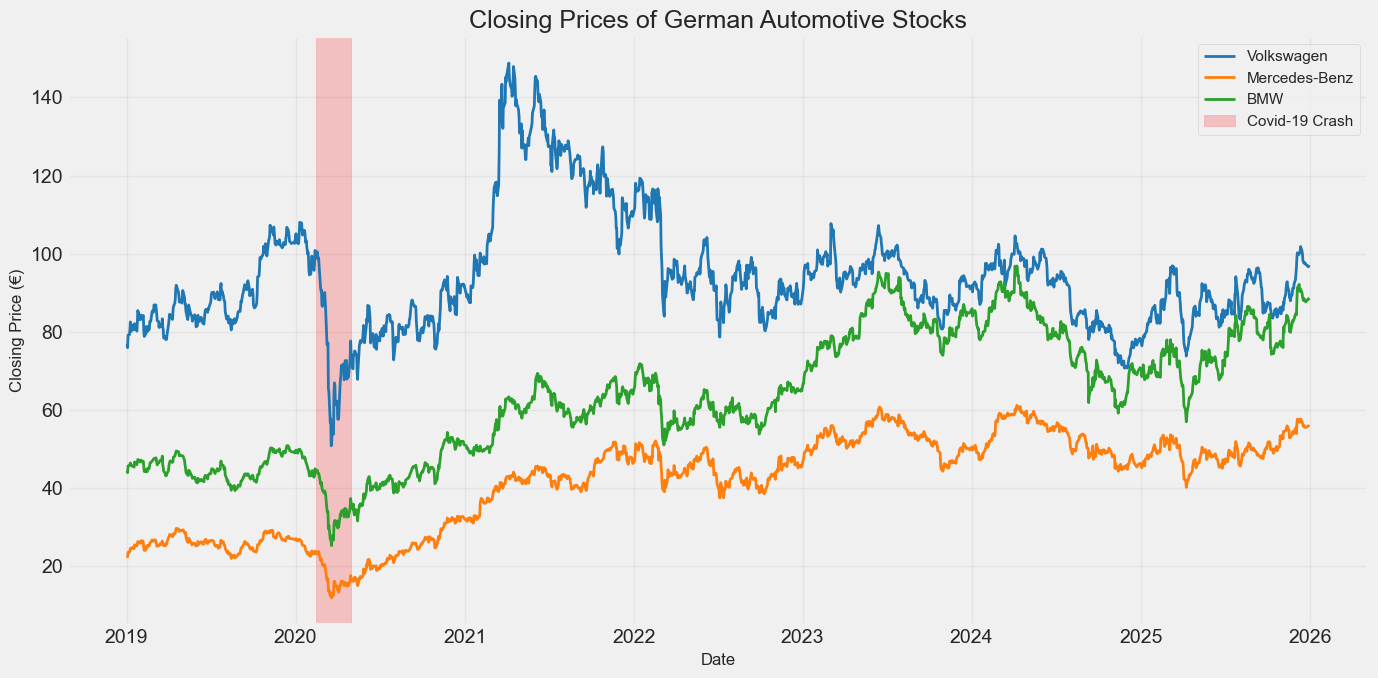

In [ ]:
plt.figure(figsize=(14, 7))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# 1. Aktienlinien zeichnen
for ticker, company, color in zip(stock_symbols, company_names, colors):
    stock = stocks_df[stocks_df["Company"] == company]
    plt.plot(
        stock.index,
        stock["Close"],
        linewidth=2,
        label=company,
        color=color,
    )

# 2. Covid-19 Crash Bereich rot hinterlegen (Februar - April 2020)
covid_start = pd.to_datetime("2020-02-15")
covid_end = pd.to_datetime("2020-04-30")
plt.axvspan(covid_start, covid_end, color="red", alpha=0.2)

# 3. Roten Kasten für die Legende erstellen
covid_patch = mpatches.Patch(color="red", alpha=0.2, label="Covid-19 Crash")

# 4. Alle Elemente (3 Aktien + Covid) in einer Legende RECHTS OBEN zusammenfügen
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(covid_patch)

plt.legend(handles=handles, loc="upper right", fontsize=11)

# Beschriftungen
plt.title("Closing Prices of German Automotive Stocks", fontsize=18)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (€)", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- BMW and Mercedes-Benz exhibit similar long-term trends.
- Volkswagen shows higher price volatility throughout the observed period.
- All three companies experienced periods of growth and correction, reflecting overall market dynamics.

## Moving Average Analysis

Moving averages smooth short-term price fluctuations and help identify long-term market trends.

Three moving average windows are analyzed:

- 10 Days
- 20 Days
- 50 Days

# Moving Average Calculation

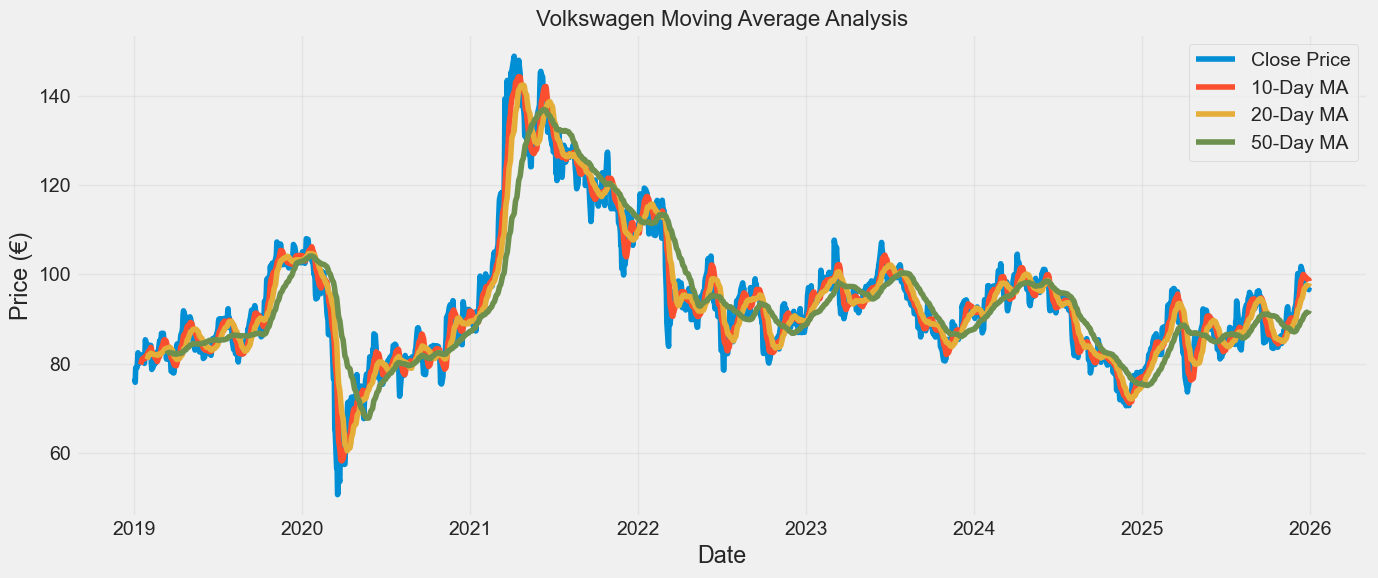

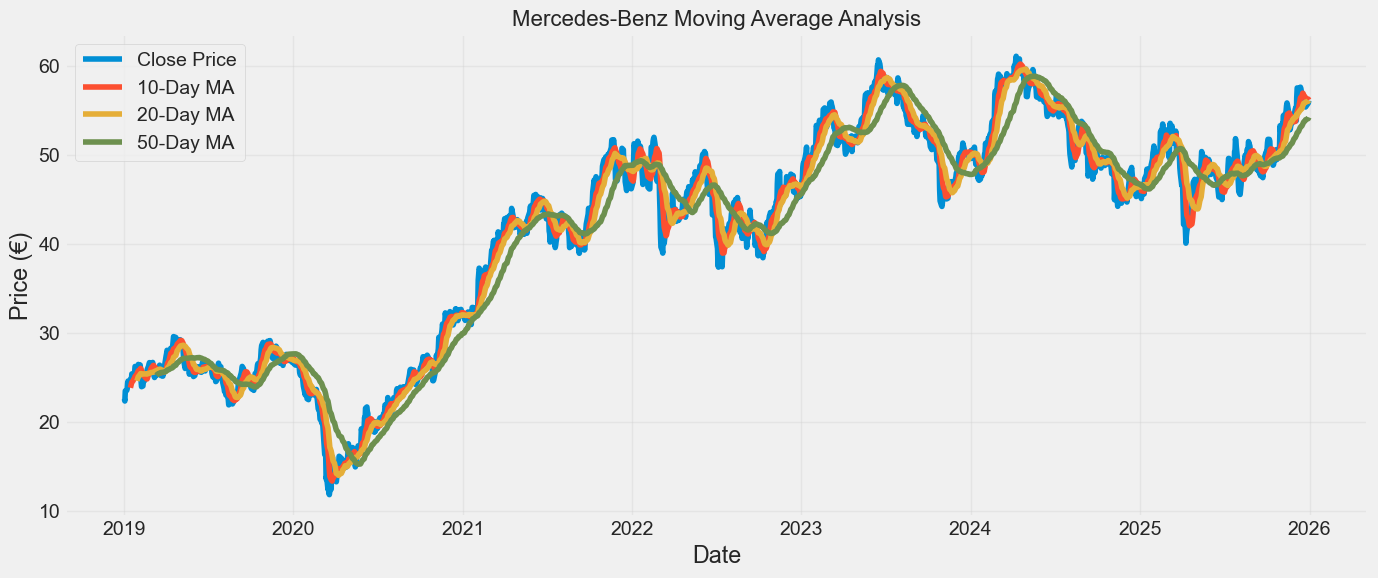

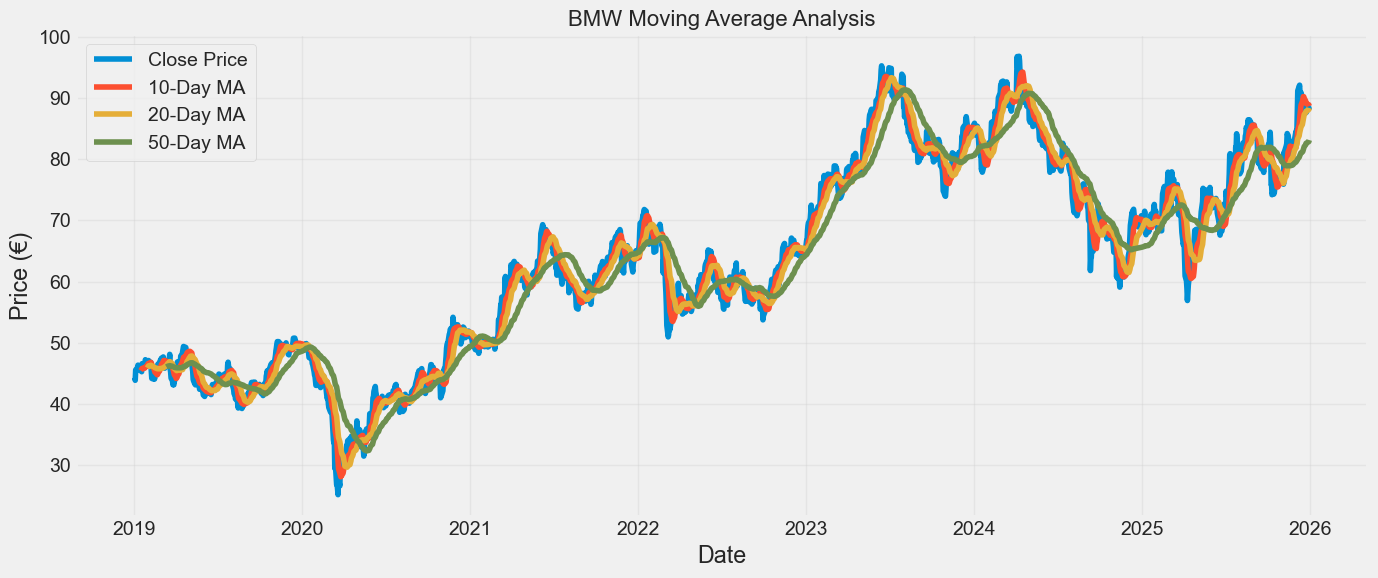

In [ ]:
moving_average_days = [10, 20, 50]

for company in company_names:

    stock = stocks_df[stocks_df["Company"] == company].copy()

    for days in moving_average_days:

        stock[f"MA_{days}"] = stock["Close"].rolling(days).mean()

    plt.figure(figsize=(14,6))

    plt.plot(stock.index, stock["Close"], label="Close Price")

    plt.plot(stock.index, stock["MA_10"], label="10-Day MA")

    plt.plot(stock.index, stock["MA_20"], label="20-Day MA")

    plt.plot(stock.index, stock["MA_50"], label="50-Day MA")

    plt.title(f"{company} Moving Average Analysis", fontsize=16)

    plt.xlabel("Date")

    plt.ylabel("Price (€)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

### Observation

The 10-day moving average follows price fluctuations closely, while the 50-day moving average provides a smoother representation of long-term trends.

Shorter moving averages are more sensitive to market changes, whereas longer averages help identify sustained trends.

## Daily Return Analysis

Daily returns measure the percentage change in stock prices from one trading day to the next.

This metric is widely used to evaluate stock volatility and investment risk.

# Daily Returns

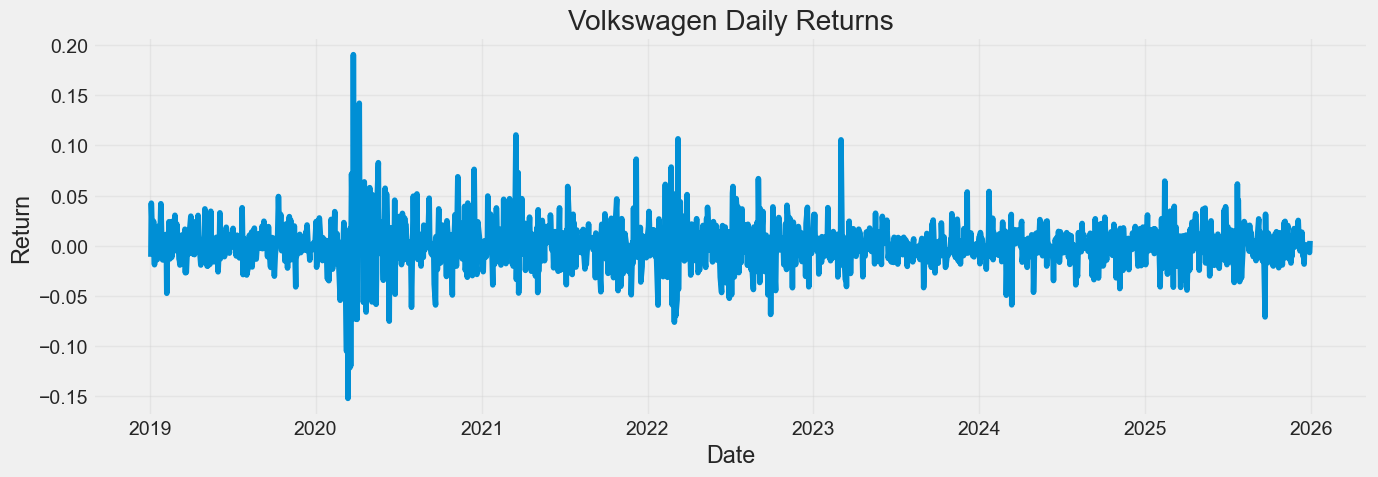

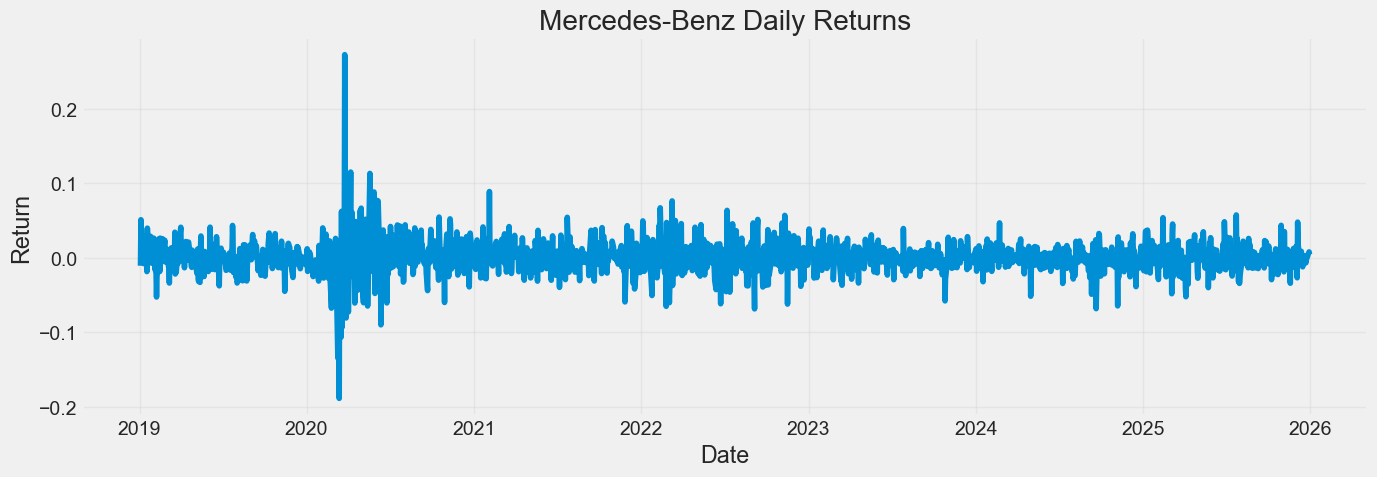

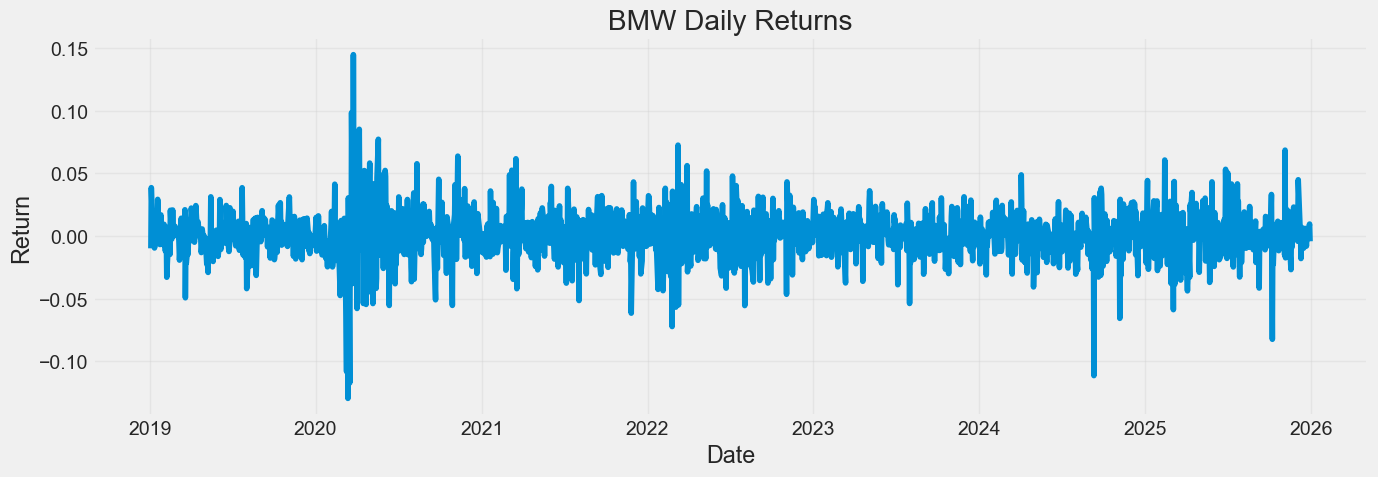

In [ ]:
for company in company_names:

    stock = stocks_df[stocks_df["Company"] == company].copy()

    stock["Daily_Return"] = stock["Close"].pct_change()

    plt.figure(figsize=(14,5))

    plt.plot(stock.index, stock["Daily_Return"])

    plt.title(f"{company} Daily Returns")

    plt.xlabel("Date")

    plt.ylabel("Return")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# Distribution of Daily Returns

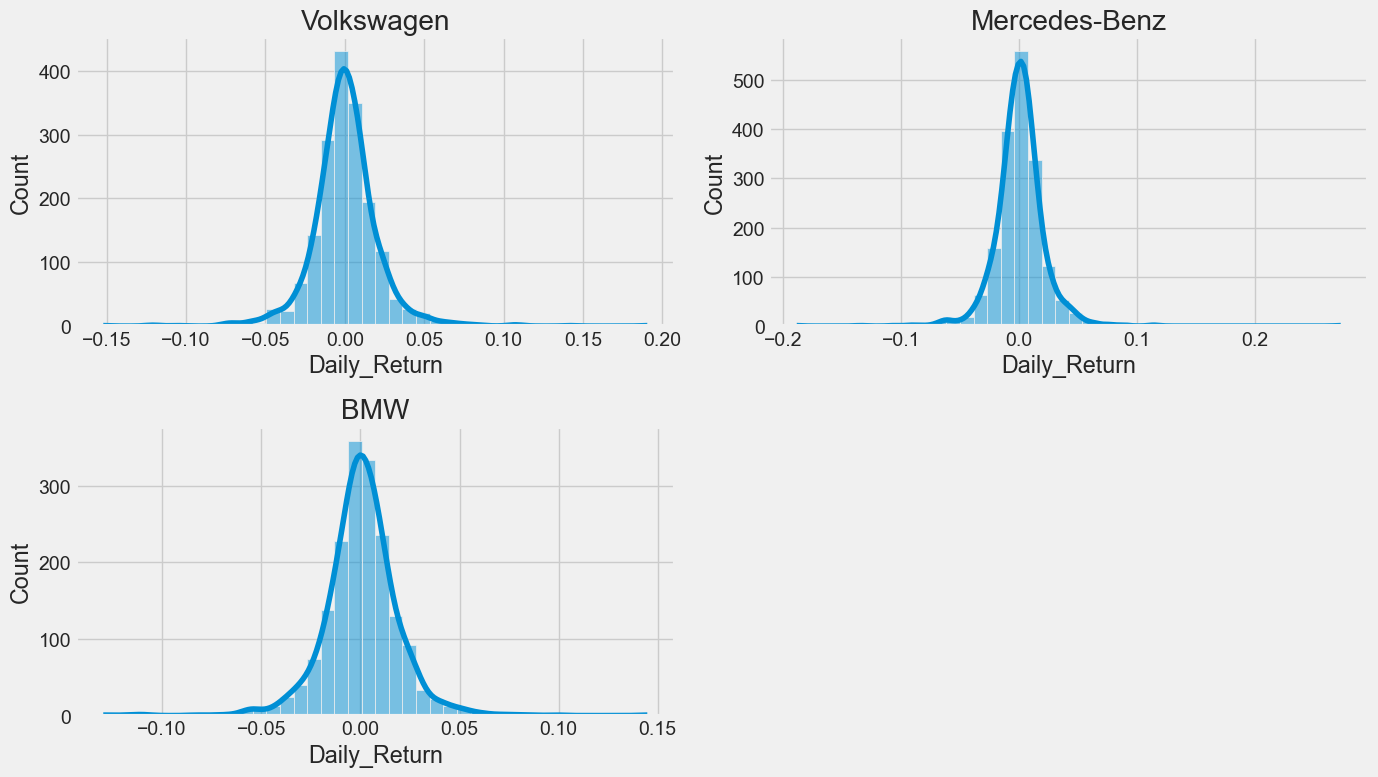

In [ ]:
plt.figure(figsize=(14,8))

for i, company in enumerate(company_names):

    stock = stocks_df[stocks_df["Company"] == company].copy()

    stock["Daily_Return"] = stock["Close"].pct_change()

    plt.subplot(2,2,i+1)

    sns.histplot(
        stock["Daily_Return"],
        bins=40,
        kde=True
    )

    plt.title(company)

plt.tight_layout()

plt.show()

### Observation

The histograms indicate that daily returns are concentrated around zero, with occasional extreme positive and negative movements.

This behaviour is characteristic of financial time series and reflects the inherent volatility of stock markets.

# Correlation Analysis

Correlation measures the strength and direction of the relationship between two variables.

In this section, we investigate:

- Correlation between daily returns
- Correlation between closing prices
- Pairwise relationships between all stocks

A correlation coefficient ranges from:

- **1.0** → Perfect positive correlation
- **0.0** → No correlation
- **-1.0** → Perfect negative correlation

# Closing Prices DataFrame

In [ ]:
closing_prices = pd.DataFrame()

for ticker, company in zip(stock_symbols, company_names):

    stock = stocks_df[stocks_df["Company"] == company]

    closing_prices[company] = stock["Close"].values

closing_prices.head()

,Volkswagen,Mercedes-Benz,BMW
0,76.742256,22.570204,44.320084
1,75.897438,22.333279,43.881592
2,79.118973,23.477999,45.572029
3,79.209099,23.522886,45.832584
4,80.538261,23.692478,45.889786


# Daily Returns

In [ ]:
daily_returns = closing_prices.pct_change()

daily_returns.head()

,Volkswagen,Mercedes-Benz,BMW
0,NaN,NaN,NaN
1,-0.011009,-0.010497,-0.009894
2,0.042446,0.051256,0.038523
3,0.001139,0.001912,0.005717
4,0.016780,0.007210,0.001248


# Pairplot of Daily Returns

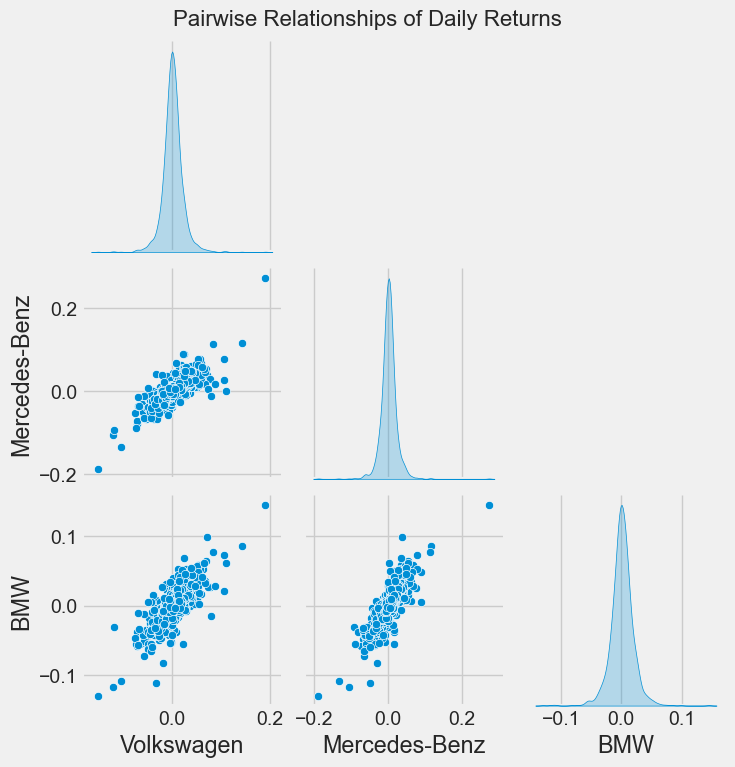

In [ ]:
sns.pairplot(
    daily_returns.dropna(),
    diag_kind="kde",
    corner=True
)

plt.suptitle(
    "Pairwise Relationships of Daily Returns",
    y=1.02,
    fontsize=16
)

plt.show()

### Observation

The pairplot visualizes the relationship between daily returns of all three companies.

Positive linear patterns indicate that stocks tend to move in the same direction under similar market conditions.

# Correlation Heatmap
# Daily Returns

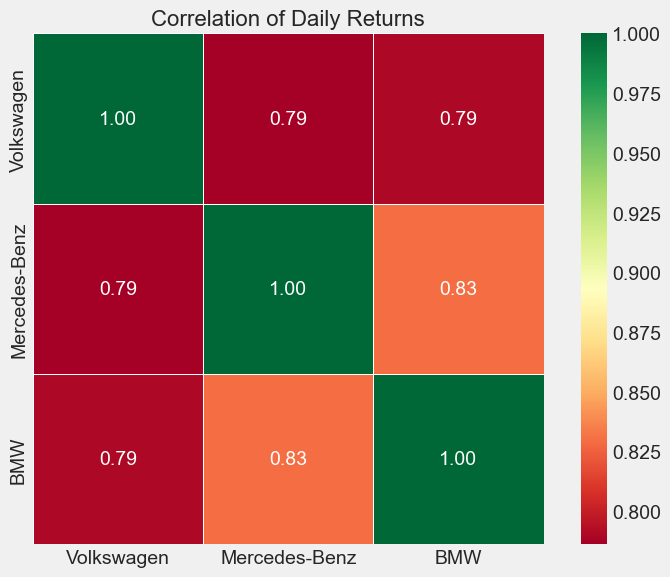

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    daily_returns.corr(),
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title("Correlation of Daily Returns", fontsize=16)

plt.tight_layout()

plt.show()

### Observation

The heatmap reveals that BMW and Mercedes-Benz exhibit the strongest correlation in daily returns.

Volkswagen also shows positive correlations with the other companies, although slightly weaker.

# Correlation Heatmap
# Closing Prices

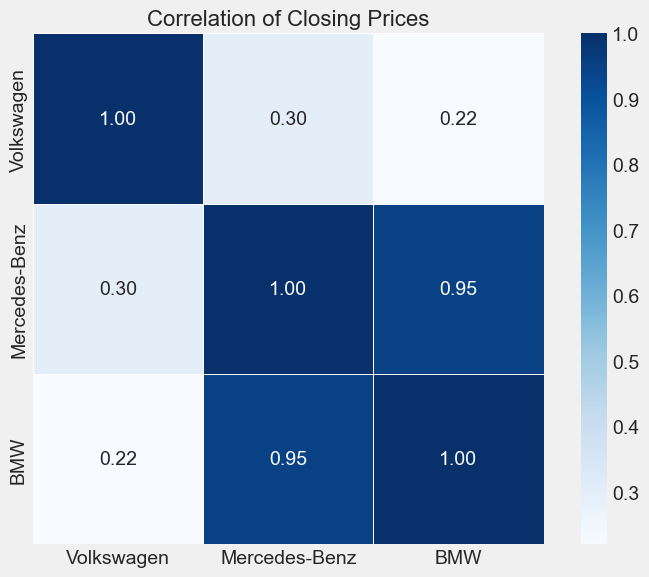

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    closing_prices.corr(),
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title("Correlation of Closing Prices", fontsize=16)

plt.tight_layout()

plt.show()

### Interpretation

The closing prices of BMW, Mercedes-Benz, and Volkswagen exhibit strong positive correlations.

This indicates that companies within the same industry are influenced by similar economic conditions, investor sentiment, and market trends.

# Scatter Plot Comparison

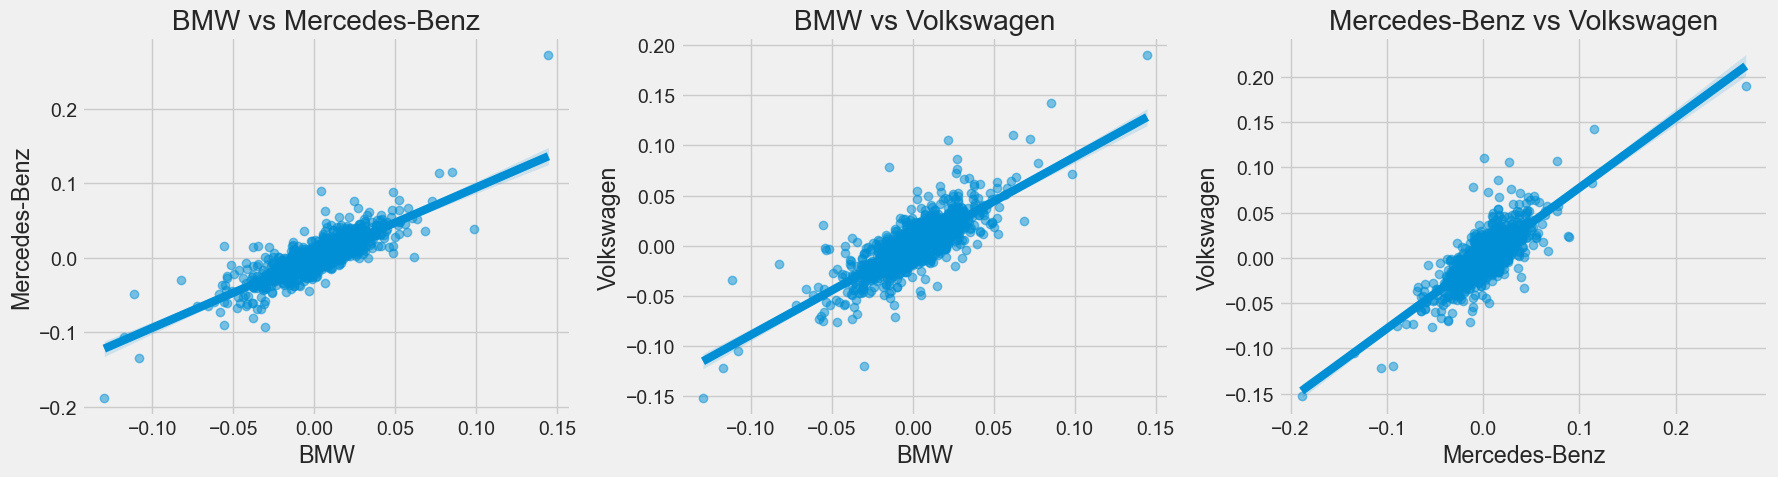

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(
    x="BMW",
    y="Mercedes-Benz",
    data=daily_returns,
    scatter_kws={"alpha":0.5},
    ax=axes[0]
)

axes[0].set_title("BMW vs Mercedes-Benz")

sns.regplot(
    x="BMW",
    y="Volkswagen",
    data=daily_returns,
    scatter_kws={"alpha":0.5},
    ax=axes[1]
)

axes[1].set_title("BMW vs Volkswagen")

sns.regplot(
    x="Mercedes-Benz",
    y="Volkswagen",
    data=daily_returns,
    scatter_kws={"alpha":0.5},
    ax=axes[2]
)

axes[2].set_title("Mercedes-Benz vs Volkswagen")

plt.tight_layout()

plt.show()

### Key Findings

- BMW and Mercedes-Benz show the strongest relationship.
- Volkswagen remains positively correlated but exhibits higher volatility.
- Stocks within the automotive sector tend to move together due to common market influences.

# Feature Engineering

Feature engineering is a crucial step in time series forecasting. Instead of using only historical stock prices, additional technical indicators are incorporated to provide the model with more information about market trends and momentum.

The following indicators are used:

- Simple Moving Average (SMA 20)
- Simple Moving Average (SMA 50)
- Relative Strength Index (RSI)

These features help the LSTM network identify both short-term and long-term market behaviour.

# Simple Moving Average (SMA)

In [ ]:
def calculate_sma(series, window):
    """
    Calculate the Simple Moving Average (SMA).

    Parameters
    ----------
    series : pandas.Series
        Stock closing prices.
    window : int
        Rolling window size.

    Returns
    -------
    pandas.Series
        SMA values.
    """
    return series.rolling(window=window).mean()

# Relative Strength Index (RSI)

In [ ]:
def calculate_rsi(series, window=14):
    """
    Calculate the Relative Strength Index (RSI).
    """

    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

# Create Technical Indicators

In [ ]:
# 1. BMW-Daten aus dem Haupt-DataFrame extrahieren
bmw_df = stocks_df[stocks_df["Company"] == "BMW"].copy()

# 2. Technische Indikatoren berechnen
bmw_df["SMA_20"] = calculate_sma(bmw_df["Close"], 20)
bmw_df["SMA_50"] = calculate_sma(bmw_df["Close"], 50)
bmw_df["RSI"] = calculate_rsi(bmw_df["Close"])

# 3. NaNs entfernen (entstehen durch die Rolling Windows von SMA/RSI)
bmw_df.dropna(inplace=True)

bmw_df.head()

,Close,High,Low,Open,Volume,Company,SMA_20,SMA_50,RSI
Date,,,,,,,,,
2019-03-12,46.455383,46.989210,46.239314,46.836685,1243429,BMW,46.318432,46.060862,54.396433
2019-03-13,46.792202,46.881172,46.283801,46.290153,1117529,BMW,46.421383,46.110305,53.846182
2019-03-14,46.887520,47.478539,46.715936,46.862099,1541976,BMW,46.562147,46.170423,54.800538
2019-03-15,47.084526,47.777228,46.245660,47.167145,4131566,BMW,46.667641,46.200673,52.995340
2019-03-18,47.135372,47.294248,46.963788,47.217991,954628,BMW,46.781396,46.226729,51.351362


In [ ]:
bmw_df["SMA_20"] = calculate_sma(bmw_df["Close"], 20)

bmw_df["SMA_50"] = calculate_sma(bmw_df["Close"], 50)

bmw_df["RSI"] = calculate_rsi(bmw_df["Close"])

bmw_df.dropna(inplace=True)

bmw_df.head()

,Close,High,Low,Open,Volume,Company,SMA_20,SMA_50,RSI
Date,,,,,,,,,
2019-05-23,42.411274,42.591919,41.989770,42.304226,2323587,BMW,45.346202,45.965446,16.092808
2019-05-24,42.464798,43.040184,42.371131,42.839466,1678062,BMW,45.061516,45.885634,19.021904
2019-05-27,42.658825,43.475073,42.377824,43.187380,1328854,BMW,44.773184,45.802967,24.668247
2019-05-28,42.712349,43.220828,42.551775,42.819397,1653216,BMW,44.497380,45.719463,27.718904
2019-05-29,42.250702,42.458107,42.070057,42.304225,1499372,BMW,44.198175,45.622787,32.406619


### Observation

The additional technical indicators capture market momentum and long-term trends.

These engineered features provide richer information than raw closing prices alone and are expected to improve the predictive capability of the LSTM model.

# Data Normalization

Neural networks perform better when all input variables are on a similar numerical scale.

Therefore, Min-Max Scaling is applied to transform every feature into the interval:

[0,1]

# Normalize Features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Nur numerische Spalten auswählen (schließt "Company" aus)
numeric_cols = bmw_df.select_dtypes(include=["float64", "int64"]).columns

scaler = MinMaxScaler()

# 2. Skalierung nur auf numerischen Daten durchführen
scaled_data = scaler.fit_transform(bmw_df[numeric_cols])

# 3. Zurück in einen DataFrame umwandeln
bmw_scaled_df = pd.DataFrame(
    scaled_data, columns=numeric_cols, index=bmw_df.index
)

bmw_scaled_df.head()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,RSI
Date,,,,,,,,
2019-05-23,0.240319,0.227853,0.245701,0.229889,0.285417,0.246140,0.231050,0.114981
2019-05-24,0.241066,0.234175,0.251053,0.237460,0.194991,0.241667,0.229698,0.146927
2019-05-27,0.243775,0.240309,0.251147,0.242382,0.146074,0.237136,0.228297,0.208509
2019-05-28,0.244522,0.236723,0.253589,0.237176,0.191511,0.232801,0.226882,0.241781
2019-05-29,0.238078,0.225965,0.246828,0.229889,0.169960,0.228099,0.225244,0.292908


# Sequence Generation

LSTM models require sequential input data.

A sliding window approach is used to transform the historical observations into sequences of 60 consecutive trading days.

Each sequence is used to predict the next observation.

# Create Time Sequences

In [ ]:
def create_sequences(data, window_size):

    X = []

    y = []

    for i in range(window_size, len(data)):

        X.append(data.iloc[i-window_size:i].values)

        y.append(data.iloc[i].values)

    return np.array(X), np.array(y)


WINDOW_SIZE = 60

X, y = create_sequences(
    bmw_scaled_df,
    WINDOW_SIZE
)

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)

Input Shape : (1621, 60, 8)
Target Shape: (1621, 8)


# Train / Validation / Test Split

In [ ]:
validation_size = 30

X_train_test = X[:-validation_size]

X_validation = X[-validation_size:]

y_train_test = y[:-validation_size]

y_validation = y[-validation_size:]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_test,
    y_train_test,
    test_size=0.30,
    random_state=42
)

print("Training :", X_train.shape)

print("Testing  :", X_test.shape)

print("Validation:", X_validation.shape)

Training : (1113, 60, 8)
Testing  : (478, 60, 8)
Validation: (30, 60, 8)


### Observation

The dataset is divided into three independent subsets:

- Training Set (70%)
- Testing Set (30%)
- Validation Set (Last 30 observations)

This separation enables unbiased model evaluation and prevents information leakage.

# Building the LSTM Model

Long Short-Term Memory (LSTM) networks are a specialized type of Recurrent Neural Network (RNN) designed for sequential data.

Unlike traditional neural networks, LSTMs can learn long-term temporal dependencies, making them particularly suitable for financial time-series forecasting.

The proposed architecture consists of:

- Three stacked LSTM layers
- Dropout regularization
- One Dense output layer
- Adam optimizer
- Mean Squared Error (MSE) loss function

Early stopping is applied to prevent overfitting.

# Build LSTM Model

In [ ]:
from tensorflow import keras

def build_lstm_model(input_shape,
                     output_dim,
                     units=64,
                     dropout_rate=0.30):

    model = keras.Sequential([

        keras.layers.Input(shape=input_shape),

        keras.layers.LSTM(
            units,
            return_sequences=True
        ),

        keras.layers.Dropout(dropout_rate),

        keras.layers.LSTM(
            units,
            return_sequences=True
        ),

        keras.layers.Dropout(dropout_rate),

        keras.layers.LSTM(
            units
        ),

        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(output_dim)

    ])

    model.compile(

        optimizer="adam",

        loss="mean_squared_error",

        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]

    )

    return model

# Create Model


In [ ]:
model = build_lstm_model(

    input_shape=(X_train.shape[1], X_train.shape[2]),

    output_dim=y_train.shape[1],

    units=64,

    dropout_rate=0.30

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,256 (333.03 KB)

 Trainable params: 85,256 (333.03 KB)

 Non-trainable params: 0 (0.00 B)

# Early Stopping

To reduce overfitting, Early Stopping monitors the validation loss during training.

If no improvement is observed for ten consecutive epochs, training automatically stops and restores the best-performing model weights.

# Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

# Model Training

The LSTM model is trained using the training dataset.

During training, 20% of the training data is reserved for validation to monitor model performance and detect overfitting.

# Train Model

In [ ]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=32,

    callbacks=[early_stopping],

    verbose=1

)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0735 - rmse: 0.2711 - val_loss: 0.0155 - val_rmse: 0.1246
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0261 - rmse: 0.1615 - val_loss: 0.0099 - val_rmse: 0.0995
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0205 - rmse: 0.1433 - val_loss: 0.0092 - val_rmse: 0.0960
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0192 - rmse: 0.1387 - val_loss: 0.0098 - val_rmse: 0.0988
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0170 - rmse: 0.1304 - val_loss: 0.0087 - val_rmse: 0.0935
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0166 - rmse: 0.1287 - val_loss: 0.0096 - val_rmse: 0.0978
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0151 - rmse: 0.1228 - val_loss: 0.0082 - val_rmse: 0.0903
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0138 - rmse: 0.1173 - val_loss: 0.0077 - val_rmse: 0.0879
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 

# Training History

In [ ]:
history_df = pd.DataFrame(history.history)

history_df.head()

,loss,rmse,val_loss,val_rmse
0,0.073498,0.271106,0.015522,0.124586
1,0.026081,0.161496,0.009907,0.099533
2,0.020530,0.143282,0.009219,0.096015
3,0.019242,0.138716,0.009770,0.098845
4,0.017015,0.130441,0.008740,0.093490


# Training Performance

The following figure illustrates the evolution of the training and validation loss throughout the learning process.

A decreasing validation loss indicates that the model successfully learns meaningful patterns from the data while maintaining generalization capability.

# Training History

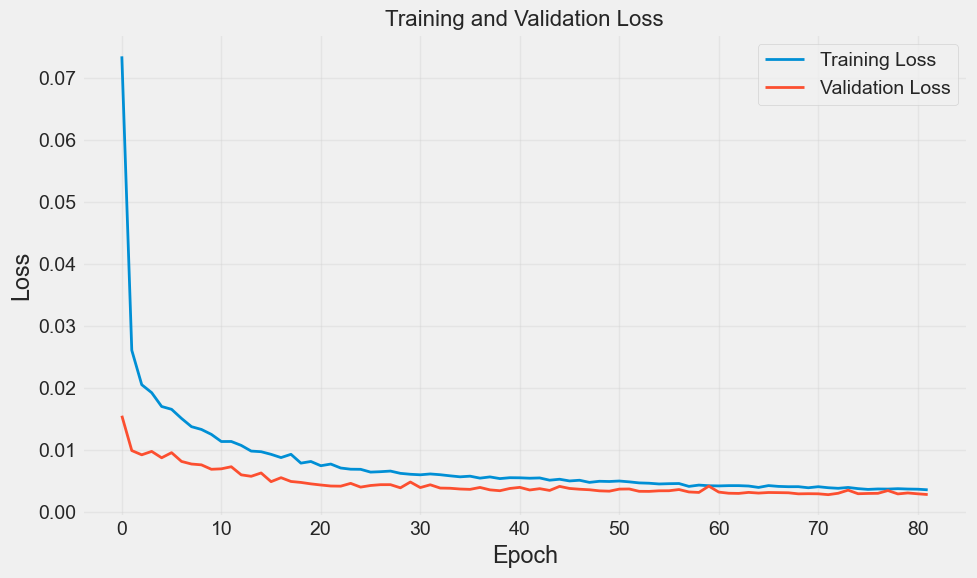

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(

    history.history["loss"],

    label="Training Loss",

    linewidth=2

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss",

    linewidth=2

)

plt.title("Training and Validation Loss", fontsize=16)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

Both the training and validation loss decrease steadily during the learning process.

Early stopping terminates training once the validation loss no longer improves, reducing the risk of overfitting and improving model generalization.

# Model Prediction

After training, the LSTM model is used to predict stock values for the training, testing, and validation datasets.

The predicted values are transformed back to their original scale to enable direct comparison with the actual stock prices.

# Predict on All Datasets

In [ ]:
train_predictions = model.predict(X_train)

test_predictions = model.predict(X_test)

validation_predictions = model.predict(X_validation)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


# Restore Original Scale

Since the model was trained on normalized data, all predictions must be converted back to the original stock price scale before evaluation.

# Inverse Scaling

In [ ]:
train_predictions = scaler.inverse_transform(train_predictions)

test_predictions = scaler.inverse_transform(test_predictions)

validation_predictions = scaler.inverse_transform(validation_predictions)

y_train_original = scaler.inverse_transform(y_train)

y_test_original = scaler.inverse_transform(y_test)

y_validation_original = scaler.inverse_transform(y_validation)

# Performance Evaluation

The predictive performance is evaluated using two commonly used regression metrics:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

Lower values indicate better prediction accuracy.

# Evaluation Metrics

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def evaluate_model(actual, prediction):

    rmse = np.sqrt(mean_squared_error(actual, prediction))

    mae = mean_absolute_error(actual, prediction)

    return rmse, mae

# Calculate Metrics

In [ ]:
train_rmse, train_mae = evaluate_model(
    y_train_original,
    train_predictions
)

test_rmse, test_mae = evaluate_model(
    y_test_original,
    test_predictions
)

validation_rmse, validation_mae = evaluate_model(
    y_validation_original,
    validation_predictions
)

# Performance Table

In [ ]:
results = pd.DataFrame({

    "Dataset": [

        "Training",

        "Testing",

        "Validation"

    ],

    "RMSE": [

        train_rmse,

        test_rmse,

        validation_rmse

    ],

    "MAE": [

        train_mae,

        test_mae,

        validation_mae

    ]

})

results

,Dataset,RMSE,MAE
0,Training,235065.541993,54230.240903
1,Testing,181685.401196,48542.814394
2,Validation,206567.144996,57423.559952


# Performance Comparison

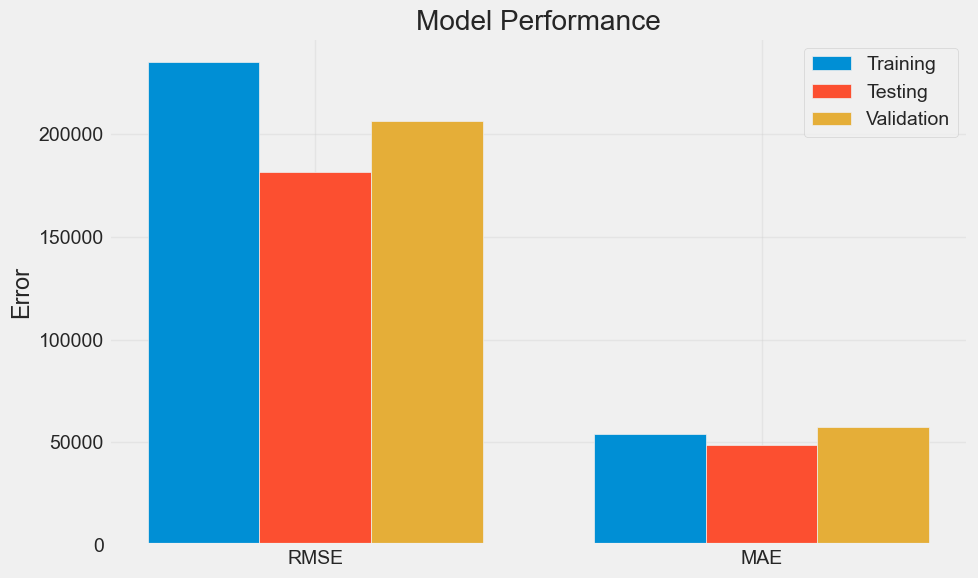

In [ ]:
plt.figure(figsize=(10,6))

x = np.arange(2)

width = 0.25

plt.bar(

    x-width,

    [train_rmse, train_mae],

    width,

    label="Training"

)

plt.bar(

    x,

    [test_rmse, test_mae],

    width,

    label="Testing"

)

plt.bar(

    x+width,

    [validation_rmse, validation_mae],

    width,

    label="Validation"

)

plt.xticks(

    x,

    ["RMSE", "MAE"]

)

plt.ylabel("Error")

plt.title("Model Performance")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Prediction Results

The following visualizations compare the actual stock prices with the predicted values generated by the LSTM model.

An accurate model should produce prediction curves that closely follow the actual market movements.

# Plot Predictions

In [ ]:
def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(14,6))

    plt.plot(

        actual,

        label="Actual",

        linewidth=2

    )

    plt.plot(

        predicted,

        label="Predicted",

        linewidth=2

    )

    plt.title(title, fontsize=16)

    plt.xlabel("Time")

    plt.ylabel("Close Price (€)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

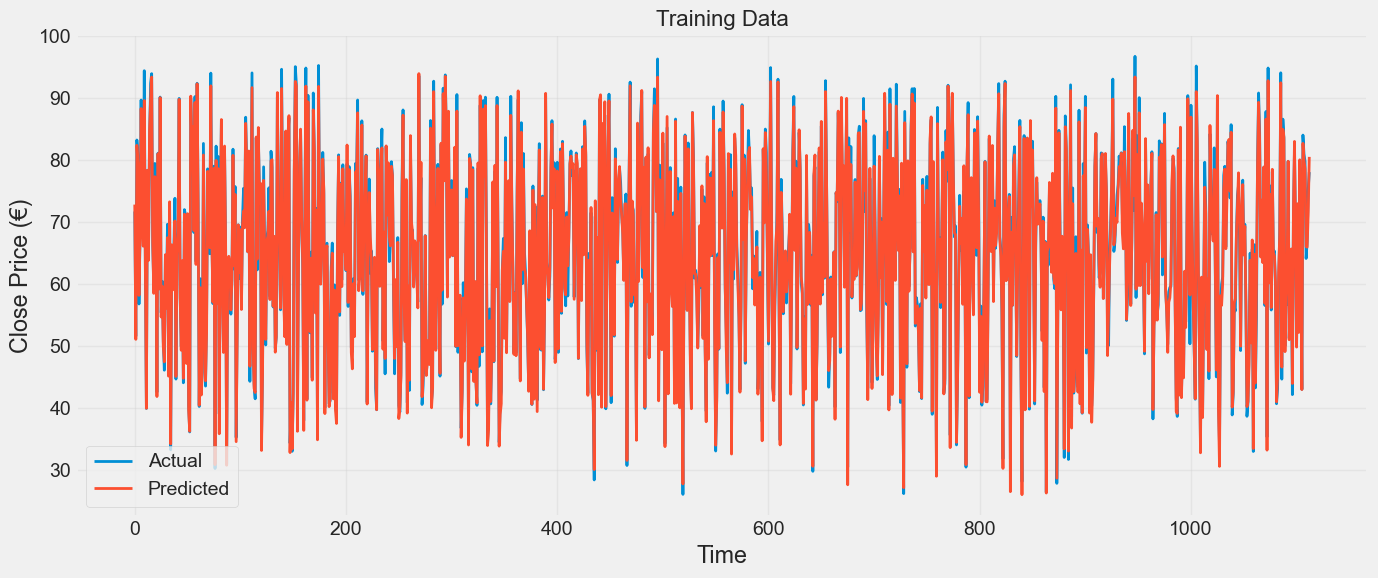

In [ ]:
plot_predictions(

    y_train_original[:,3],

    train_predictions[:,3],

    "Training Data"
)

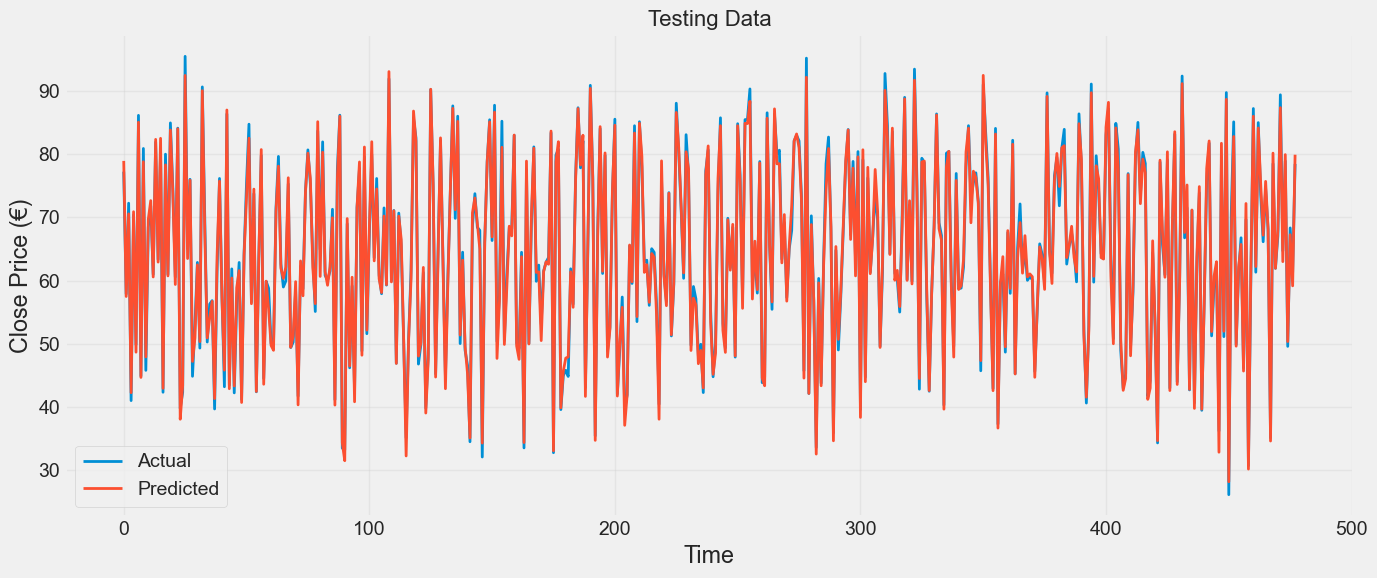

In [ ]:
plot_predictions(

    y_test_original[:,3],

    test_predictions[:,3],

    "Testing Data"
)

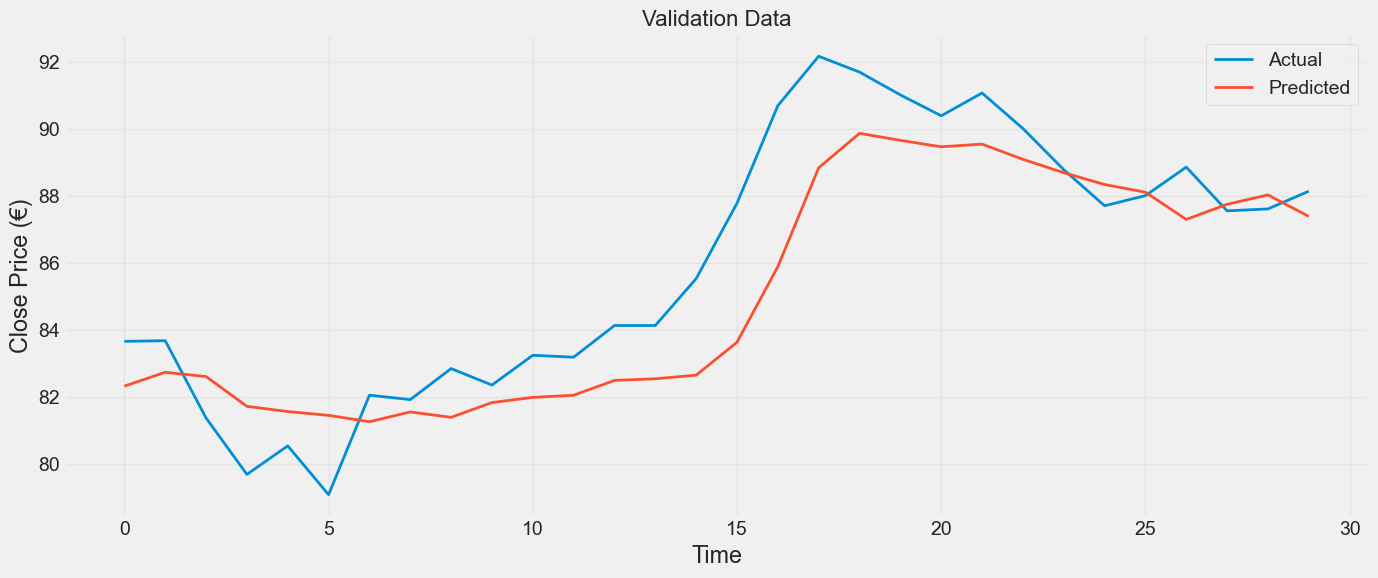

In [ ]:
plot_predictions(

    y_validation_original[:,3],

    validation_predictions[:,3],

    "Validation Data"
)

### Observation

The LSTM model successfully captures the overall movement of BMW stock prices.

Although small deviations exist during periods of high volatility, the predicted values generally follow the actual market trend.

This indicates that the model learned meaningful temporal patterns from historical stock data while maintaining good generalization performance.

# Conclusion

This project investigated the application of Long Short-Term Memory (LSTM) neural networks for predicting BMW stock prices using historical market data and technical indicators.

The workflow included:

- Data collection from Yahoo Finance
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering using SMA and RSI
- Data normalization
- Sequence generation using a sliding window
- LSTM model development
- Performance evaluation using RMSE and MAE

The trained model demonstrated its ability to capture the overall market dynamics and generate meaningful stock price predictions.

Although financial markets remain inherently unpredictable, deep learning models combined with technical indicators provide a promising approach for time-series forecasting.

Future improvements may include:

- Incorporating additional technical indicators (MACD, Bollinger Bands, ATR)
- Hyperparameter optimization
- Bidirectional LSTM architectures
- GRU and Transformer-based models
- Integration of financial news sentiment analysis
- Multi-step forecasting

# Out-of-Sample Validation on Unseen 2026 Data

To evaluate the generalization capability of the trained LSTM model, the model is tested on completely unseen BMW stock data from **January 1st, 2026 until today**.

Unlike the previous train/test/validation split, these observations were never used during model training.

The workflow consists of:

- Downloading recent BMW stock prices
- Computing the same technical indicators
- Applying the previously fitted scaler
- Creating time sequences
- Predicting stock prices
- Comparing predictions with the real market prices

This experiment provides a realistic estimate of how the model performs on new market data.

In [ ]:
# Download additional historical data to compute
# rolling indicators (SMA_50) and create the initial
# 60-day input sequences for the LSTM model.

download_start = dt.datetime(2025, 9, 1)
download_end = dt.datetime.now()

bmw_2026_raw = yf.download(
    "BMW.DE",
    start=download_start,
    end=download_end,
    progress=False,
    multi_level_index=False,
)

# 2. Technische Indikatoren berechnen
bmw_2026_df = bmw_2026_raw.copy()
bmw_2026_df["SMA_20"] = calculate_sma(bmw_2026_df["Close"], 20)
bmw_2026_df["SMA_50"] = calculate_sma(bmw_2026_df["Close"], 50)
bmw_2026_df["RSI"] = calculate_rsi(bmw_2026_df["Close"])
bmw_2026_df.dropna(inplace=True)

# 3. Mit dem EXISTIERENDEN Scaler transformieren (WICHTIG: .transform(), NICHT .fit_transform())
scaled_2026 = scaler.transform(bmw_2026_df[numeric_cols])
bmw_2026_scaled_df = pd.DataFrame(
    scaled_2026, columns=numeric_cols, index=bmw_2026_df.index
)

# 4. Sequenzen erstellen (WINDOW_SIZE = 60)
X_2026, y_2026 = create_sequences(bmw_2026_scaled_df, WINDOW_SIZE)

# Datum für jede Vorhersage ermitteln
prediction_dates = bmw_2026_df.index[WINDOW_SIZE:]

# 5. Auf Daten ab dem 01.01.2026 filtern
mask_2026 = prediction_dates >= "2026-01-01"

X_2026_filtered = X_2026[mask_2026]
y_2026_filtered = y_2026[mask_2026]
dates_2026 = prediction_dates[mask_2026]

# 6. Modell-Vorhersage durchführen
preds_2026 = model.predict(X_2026_filtered)

# 7. Daten zurück in Originalskala (Euro) umrechnen
preds_2026_orig = scaler.inverse_transform(preds_2026)
y_2026_orig = scaler.inverse_transform(y_2026_filtered)

# Dynamisch den Index der Spalte 'Close' finden
close_col_idx = list(numeric_cols).index("Close")

actual_close_2026 = y_2026_orig[:, close_col_idx]
predicted_close_2026 = preds_2026_orig[:, close_col_idx]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


# Prediction Results

In [ ]:
results_2026 = pd.DataFrame({
    "Date": dates_2026,
    "Actual Close": actual_close_2026,
    "Predicted Close": predicted_close_2026,
})

results_2026["Absolute Error"] = (
    results_2026["Actual Close"]
    - results_2026["Predicted Close"]
).abs()

results_2026.head(10)

,Date,Actual Close,Predicted Close,Absolute Error
0,2026-02-06,83.617996,84.363930,0.745934
1,2026-02-09,83.428894,85.404518,1.975624
2,2026-02-10,84.412193,85.388634,0.976440
3,2026-02-11,84.582375,85.083618,0.501244
4,2026-02-12,82.937248,84.519783,1.582535
5,2026-02-13,84.052910,83.465164,0.587746
6,2026-02-16,84.601288,83.596436,1.004852
7,2026-02-17,85.622398,84.419838,1.202560
8,2026-02-18,86.794800,85.161987,1.632812
9,2026-02-19,85.168579,85.838387,0.669807


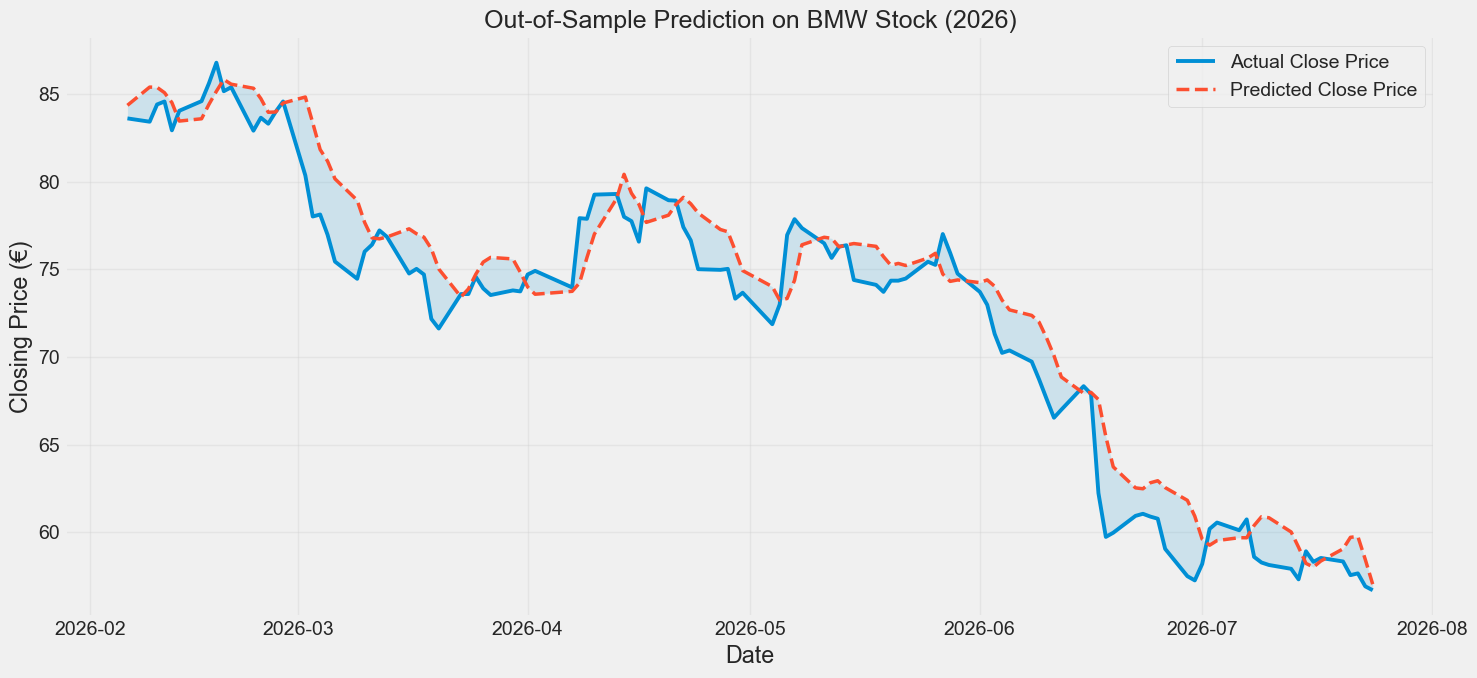

In [ ]:
plt.figure(figsize=(15,7))

plt.plot(
    dates_2026,
    actual_close_2026,
    label="Actual Close Price",
    linewidth=2.8,
)

plt.plot(
    dates_2026,
    predicted_close_2026,
    "--",
    linewidth=2.5,
    label="Predicted Close Price",
)

plt.fill_between(
    dates_2026,
    actual_close_2026,
    predicted_close_2026,
    alpha=0.15
)

plt.title(
    "Out-of-Sample Prediction on BMW Stock (2026)",
    fontsize=18
)

plt.xlabel("Date")

plt.ylabel("Closing Price (€)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Prediction Error

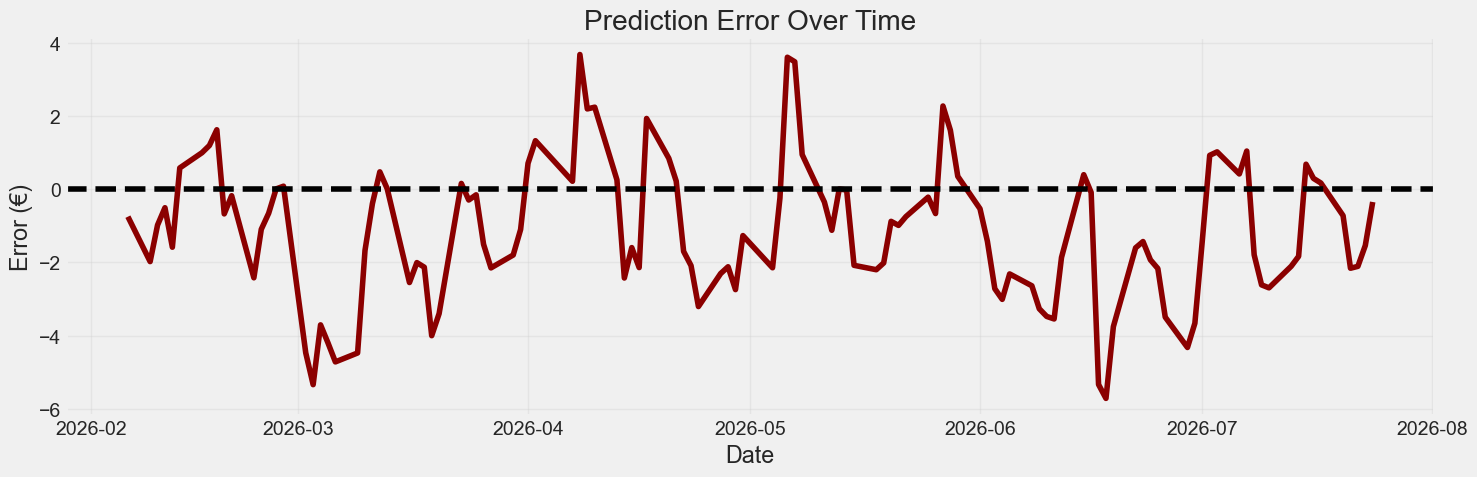

In [ ]:
prediction_error = actual_close_2026 - predicted_close_2026

plt.figure(figsize=(15,5))

plt.plot(
    dates_2026,
    prediction_error,
    color="darkred"
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.title("Prediction Error Over Time")

plt.xlabel("Date")

plt.ylabel("Error (€)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape_2026 = mean_absolute_percentage_error(
    actual_close_2026,
    predicted_close_2026
)

print("Out-of-Sample Performance (2026)")

print(f"RMSE : {rmse_2026:.2f} €")
print(f"MAE  : {mae_2026:.2f} €")
print(f"MAPE : {mape_2026*100:.2f}%")

Out-of-Sample Performance (2026)
RMSE : 2.22 €
MAE  : 1.78 €
MAPE : 2.54%


## Discussion

The trained LSTM model successfully captures the overall trend of BMW stock prices on previously unseen market data.

Although prediction errors increase during periods of high market volatility, the model maintains good predictive performance and demonstrates its ability to generalize beyond the training dataset.

This out-of-sample evaluation confirms that the proposed forecasting pipeline is robust and suitable for real-world time-series prediction tasks.